In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import pandas as pd
import numpy as np
import os
from pathlib import Path
import geopandas as gpd
import contextily as ctx
import io, zipfile, requests
import shapely

import folium
import mapclassify
from shapely.geometry import Polygon

In [2]:
# Chicago community area boundaries — download from the city data portal and cache locally
CA_PATH = Path('..') / 'data' / 'chicago_community_areas.gpkg'

if CA_PATH.exists():
    community_areas = gpd.read_file(CA_PATH)
else:
    print('Downloading Chicago community area boundaries...')
    url = 'https://data.cityofchicago.org/resource/igwz-8jzy.geojson?$limit=100'
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    community_areas = gpd.read_file(io.BytesIO(r.content))
    community_areas.to_file(CA_PATH, driver='GPKG')
    print(f'Saved {len(community_areas)} community areas to {CA_PATH}')

community_areas = community_areas.to_crs(epsg=4326)
print(f'Community areas loaded: {len(community_areas)}')

Community areas loaded: 77


In [3]:
community_areas["area_numbe"] = (
    community_areas["area_numbe"]
    .astype(int)
)


In [4]:
taxi_trips = pd.read_parquet("../data/taxi_data_processed.parquet")

pois_agg = pd.read_csv('../data/processed/chicago_pois_agg.csv')

#final_grid = pd.read_parquet(
#    "../data/final_grid.parquet"
#)

## Comparison of the different spatial entities

In [5]:
print(taxi_trips['h3_7_index_pickup'].nunique())
print(taxi_trips['h3_index_pickup'].nunique())
print(taxi_trips['h3_9_index_pickup'].nunique())
print(taxi_trips['Pickup Census Tract'].nunique())
print(taxi_trips['Pickup Community Area'].nunique())

110
360
491
495
75


In [6]:
(
    taxi_trips[["Pickup Census Tract", "h3_9_index_pickup"]]
    .drop_duplicates()
    .groupby("h3_9_index_pickup")
    .size()
    .describe()
)

count    491.000000
mean       1.008147
std        0.089982
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
dtype: float64

The number of spatial units decreases from 495 census tracts to 491 H3-9 cells, 360 H3-8 cells and 110 H3-7 cells. Due to privacy protection, pickup coordinates are mapped to census tract centroids. Consequently, the H3 discretization does not provide additional spatial detail. Instead, it creates alternative aggregation levels that allow the study of spatial smoothing and aggregation effects.

In [7]:
pickup_spatial_units = {
    "community_area": "Pickup Community Area",
    "census_tract": "Pickup Census Tract",
    "h3_7": "h3_7_index_pickup",
    "h3_8": "h3_index_pickup",
    "h3_9": "h3_9_index_pickup"
}

dropoff_spatial_units = {
    "Community Area": "Dropoff Community Area",
    "Census Tract": "Dropoff Census Tract",
    "H3 Resolution 8": "h3_index_dropoff"
}

## Demand Analysis

In [8]:
spatial_demand = (
    taxi_trips
    .groupby("h3_index_pickup")
    .size()
    .reset_index(name="trip_count")
)
#spatial_demand

In [9]:
top_demand = (
    spatial_demand
    .sort_values("trip_count", ascending=False)
    .head(20)
)

#top_demand

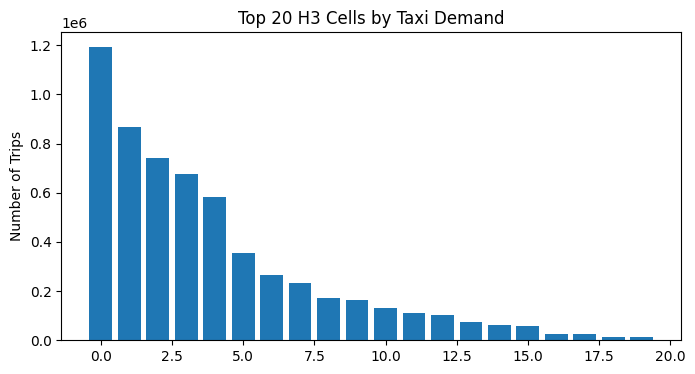

In [10]:
plt.figure(figsize=(8,4))

plt.bar(
    range(len(top_demand)),
    top_demand["trip_count"]
)

plt.title("Top 20 H3 Cells by Taxi Demand")
plt.ylabel("Number of Trips")

plt.show()

In [11]:
#Spatial aggregation

def create_spatial_statistics(df, group_column):

    stats = (
        df
        .groupby(group_column)
        .agg(

            trip_count=("Trip ID", "count"),
            unique_taxis=("Taxi ID", "nunique"),
            avg_trip_length=("Trip Miles", "mean"),
            median_trip_length=("Trip Miles", "median"),
            avg_trip_duration=("Trip Seconds", "mean"),
            avg_price=("Trip Total", "mean"),
            median_price=("Trip Total", "median"),
        )
        .reset_index()
    )

    return stats

In [12]:
#create statistics

pickup_stats = {}

for name, col in pickup_spatial_units.items():
    pickup_stats[name] = create_spatial_statistics(
        taxi_trips,
        col
    )

In [13]:
def build_h3_geodataframe(df, h3_column):

    polygons = []

    for cell in df[h3_column]:

        boundary = h3.cell_to_boundary(cell)

        polygons.append(

            Polygon(
                [(lng, lat) for lat, lng in boundary]
            )
        )

    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=polygons,
        crs="EPSG:4326"
    )

    return gdf

In [14]:
#join community areas

def build_community_geodataframe(stats):

    gdf = community_areas.merge(

        stats,
        left_on="area_numbe",
        right_on="Pickup Community Area",
        how="left"
    )

    return gdf

In [15]:
def get_hexagon_grid(data, h3_col='h3_index'):
    """
    Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source.

    Parameters
    ----------
    data : pd.DataFrame or pd.Series
        Source data. If DataFrame, all columns are kept in the output.
        If Series, the output has only 'h3_index' and 'geometry'.
    h3_col : str
        Column in `data` containing H3 cell IDs (ignored when data is a Series).

    Returns
    -------
    GeoDataFrame with all original columns plus 'geometry', CRS EPSG:4326.
    """
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        h3_list = list(data)
        df = pd.DataFrame({'h3_index': h3_list})
    else:
        h3_list = list(data[h3_col])
        df = data.reset_index(drop=True)

    geometries = [_to_polygon(cell) for cell in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs='EPSG:4326')


def create_choropleth_plot(
    gdf,
    value_col='poi_count',
    title='POI count per H3 hexagon',
    boundaries=None,
    cmap='YlOrRd',
    figsize=(6, 8),
    k=7,
):
    """
    Create a static matplotlib choropleth of hexagon values with Chicago basemap.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must contain 'geometry' and `value_col`. CRS EPSG:4326.
    value_col : str
        Column used to colour hexagons.
    title : str
        Figure title.
    boundaries : GeoDataFrame or None
        Community area outlines to overlay. Defaults to the global `community_areas`.
    cmap : str
        Matplotlib colour map name.
    figsize : tuple
        Figure size in inches.
    k : int
        Number of quantile classes for the colour scheme.

    Returns
    -------
    fig, ax
    """
    if boundaries is None:
        boundaries = community_areas

    fig, ax = plt.subplots(figsize=figsize)

    gdf_web = gdf.to_crs(epsg=3857)
    gdf_web.plot(
        ax=ax,
        column=value_col,
        cmap=cmap,
        scheme='quantiles',
        k=k,
        edgecolor='none',
        alpha=0.8,
        legend=True,
        zorder=1,
        legend_kwds=dict(
            title=value_col.replace('_', ' ').title(),
            loc='lower right',
            fontsize=8,
            title_fontsize=9,
        ),
        missing_kwds=dict(color='lightgrey', label='No data'),
    )

    # Basemap underneath everything
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)

    # Community area outlines drawn last so they sit on top of basemap and hexagons
    boundaries.to_crs(epsg=3857).boundary.plot(
        ax=ax, color='#222', linewidth=1.0, alpha=0.9, zorder=3,
    )

    ax.set_axis_off()
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    return fig, ax

In [16]:
gdfs = {}
levels = ["h3_7", "h3_8", "h3_9"]

for level in levels:

    h3_col = pickup_spatial_units[level]

    pickup_stats[level]["geometry"] = [
        Polygon(
            [(lng, lat) for lat, lng in h3.cell_to_boundary(h)]
        )
        for h in pickup_stats[level][h3_col]
    ]

    gdfs[level] = gpd.GeoDataFrame(
        pickup_stats[level],
        geometry="geometry",
        crs="EPSG:4326"
    )

    gdfs[level]["log_demand"] = np.log1p(gdfs[level]["trip_count"])

In [17]:
pickup_h3 = {}

for level in levels:

    h3_col = pickup_spatial_units[level]
    pickup_h3[level] = build_h3_geodataframe(
    pickup_stats[level],
    h3_col

)

In [18]:
gdfs["h3_7"].total_bounds

array([-87.92947302,  41.64008885, -87.51550479,  42.03305375])

In [19]:
pickup_community = build_community_geodataframe(

    pickup_stats["community_area"]

)

## Comparison of the spatial entity solutions

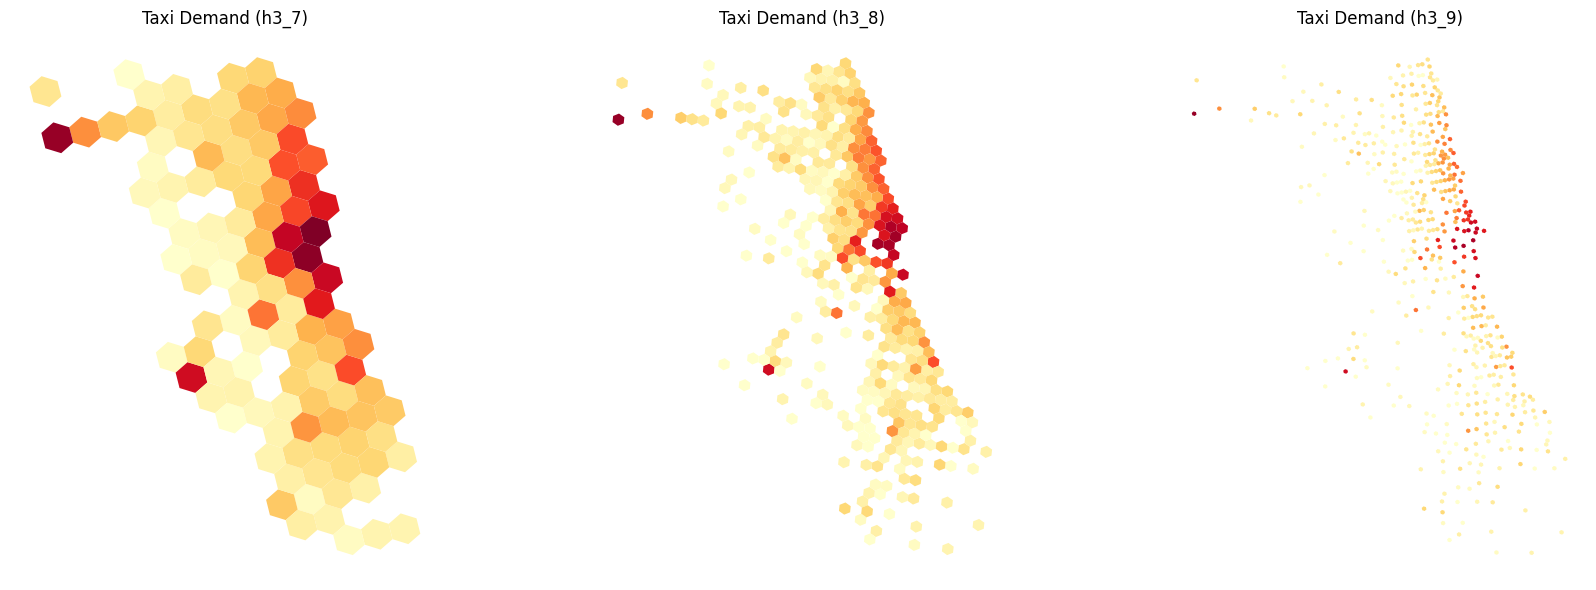

In [20]:
vmin = min(
    gdfs[level]["log_demand"].min()
    for level in levels
)
vmax = max(
    gdfs[level]["log_demand"].max()
    for level in levels
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)



for ax, level in zip(axes, levels):

    gdfs[level].plot(
        column="log_demand",
        cmap="YlOrRd",
        vmin=vmin,
        vmax=vmax,
        legend=False,
        ax=ax
    )

    ax.set_title(f"Taxi Demand ({level})")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [30]:
variables = {
    "trip_count": "Trip Count",
    "avg_trip_length": "Average Trip Length (Miles)",
    "avg_price": "Average Trip Price ($)"
}

for level in levels:

    for var, title in variables.items():

        fig, ax = create_choropleth_plot(
            pickup_h3[level],
            value_col=var,
            title=f"{title} - {level.upper()}"
        )

        fig.savefig(
            f"../docs/maps/{level}_{var}.png",
            dpi=300,
            bbox_inches="tight"
        )

        #plt.show()
        plt.close(fig)

In [32]:
for var, title in variables.items():

    fig, ax = create_choropleth_plot(
        pickup_community,
        value_col=var,
        title=f"{title} - Community Areas"
    )
    fig.savefig(
        f"../docs/maps/com-area_{var}.png",
        dpi=300,
        bbox_inches="tight"
    )

    #plt.show()
    plt.close(fig)

In [33]:
summary = pd.DataFrame()

for level, df in pickup_stats.items():

    summary.loc[level, "Number of regions"] = len(df)
    summary.loc[level, "Mean demand"] = df["trip_count"].mean()
    summary.loc[level, "Median demand"] = df["trip_count"].median()
    summary.loc[level, "Std demand"] = df["trip_count"].std()
    summary.loc[level, "Mean trip length"] = df["avg_trip_length"].mean()
    summary.loc[level, "Mean price"] = df["avg_price"].mean()
summary

,Number of regions,Mean demand,Median demand,Std demand,Mean trip length,Mean price
community_area,75.0,80137.853333,69.0,317976.203447,7.868739,2635.237311
census_tract,495.0,12146.159596,13.0,78370.391724,7.168586,2456.827079
h3_7,110.0,54657.718182,45.5,285717.156898,8.319434,2747.162569
h3_8,360.0,16700.969444,14.0,102609.127113,7.563689,2545.219265
h3_9,491.0,12245.109980,13.0,79168.213560,7.182337,2459.728004


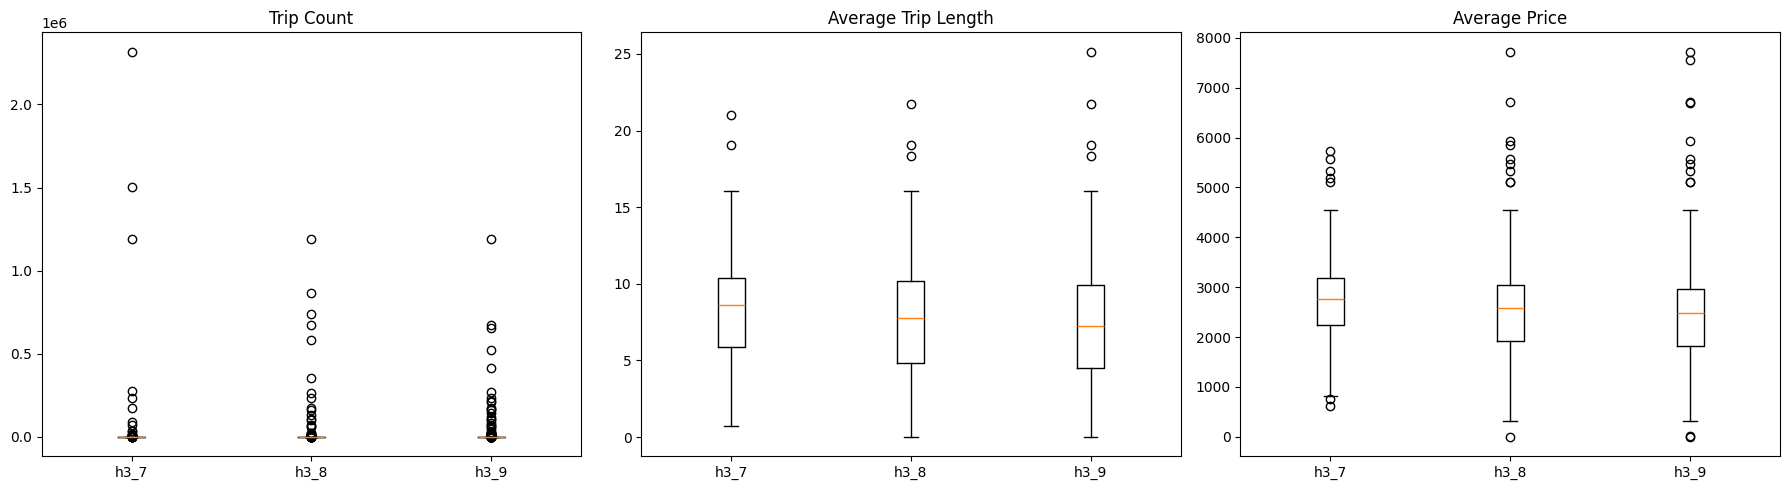

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for level in levels:

    axes[0].boxplot(
        pickup_stats[level]["trip_count"],
        positions=[levels.index(level)]
    )

axes[0].set_xticks(range(len(levels)))
axes[0].set_xticklabels(levels)
axes[0].set_title("Trip Count")


for level in levels:

    axes[1].boxplot(
        pickup_stats[level]["avg_trip_length"],
        positions=[levels.index(level)]
    )

axes[1].set_xticks(range(len(levels)))
axes[1].set_xticklabels(levels)
axes[1].set_title("Average Trip Length")


for level in levels:

    axes[2].boxplot(
        pickup_stats[level]["avg_price"],
        positions=[levels.index(level)]
    )

axes[2].set_xticks(range(len(levels)))
axes[2].set_xticklabels(levels)
axes[2].set_title("Average Price")

plt.tight_layout()
plt.show()

In [ ]:
# top-hotspots

for level in levels:

    print(f"\n===== {level.upper()} =====")

    display(

        pickup_stats[level]
        .sort_values("trip_count", ascending=False)
        .head(5)
    )


===== H3_7 =====


,h3_7_index_pickup,trip_count,unique_taxis,avg_trip_length,median_trip_length,avg_trip_duration,avg_price,median_price,geometry
25,872664c1effffff,2318073,3267,2.718373,1.23,418.278478,1438.535306,1025.0,POLYGON ((-87.63048927308355 41.90755371098675...
23,872664c1affffff,1500677,3254,2.141874,1.24,439.728015,1256.446489,1000.0,"POLYGON ((-87.63912440648137 41.8871376785664,..."
105,87275934effffff,1192882,3167,16.047805,17.41,45.692462,5563.441765,5820.0,"POLYGON ((-87.90424336171453 41.9816235768784,..."
47,872664cadffffff,278429,3143,1.792765,1.28,473.808322,1147.513926,1015.0,POLYGON ((-87.66005281769654 41.90317532606509...
24,872664c1bffffff,232285,3182,4.169528,2.52,415.652592,2003.196922,1410.0,"POLYGON ((-87.6182094435623 41.87109849035978,..."



===== H3_8 =====


,h3_index_pickup,trip_count,unique_taxis,avg_trip_length,median_trip_length,avg_trip_duration,avg_price,median_price,geometry
351,88275934edfffff,1192882,3167,16.047805,17.41,45.692462,5563.441765,5820.0,"POLYGON ((-87.90424336171453 41.9816235768784,..."
70,882664c1e3fffff,866703,3232,3.016157,1.17,390.192179,1525.434673,1000.0,POLYGON ((-87.6210014671547 41.892552912021245...
66,882664c1adfffff,739773,3191,1.681099,1.24,471.671250,1090.183976,975.0,"POLYGON ((-87.63912440648137 41.8871376785664,..."
64,882664c1a9fffff,675702,3228,2.067612,1.11,419.182619,1242.986099,975.0,POLYGON ((-87.62769200190127 41.88609596409941...
69,882664c1e1fffff,583740,3228,2.780918,1.22,413.883753,1458.850878,1025.0,"POLYGON ((-87.62574462750953 41.9000531159809,..."



===== H3_9 =====


,h3_9_index_pickup,trip_count,unique_taxis,avg_trip_length,median_trip_length,avg_trip_duration,avg_price,median_price,geometry
481,89275934ed3ffff,1192882,3167,16.047805,17.41,45.692462,5563.441765,5820.0,"POLYGON ((-87.90424336171453 41.9816235768784,..."
96,892664c1a8bffff,675702,3228,2.067612,1.11,419.182619,1242.986099,975.0,POLYGON ((-87.63314733083817 41.88255521013988...
105,892664c1e2fffff,657401,3218,2.896125,1.13,387.401867,1477.977848,975.0,POLYGON ((-87.62346990002747 41.88672050092523...
99,892664c1acfffff,523529,3150,1.695012,1.29,472.941802,1091.715053,975.0,POLYGON ((-87.64159015219968 41.88130540483686...
103,892664c1e0fffff,414027,3208,2.903907,1.19,403.940952,1501.525704,1025.0,POLYGON ((-87.62821283343483 41.89422009039774...


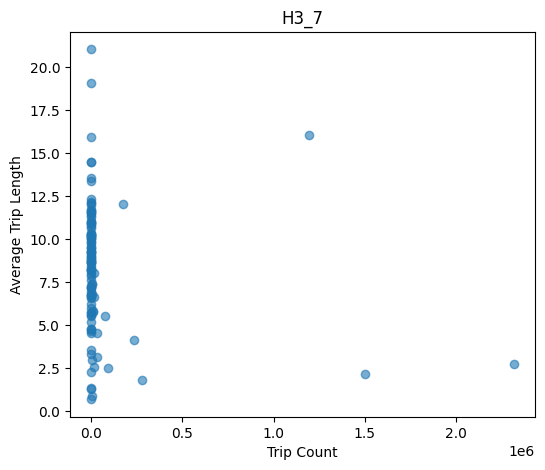

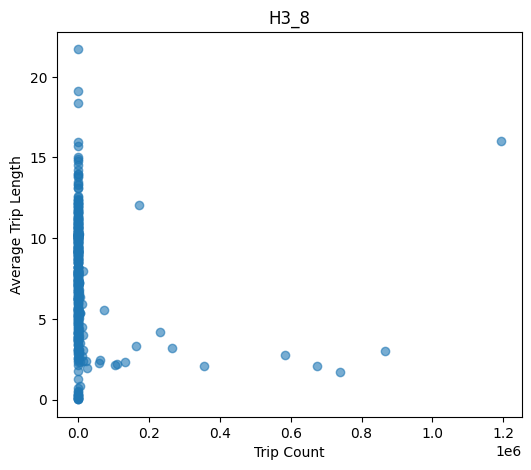

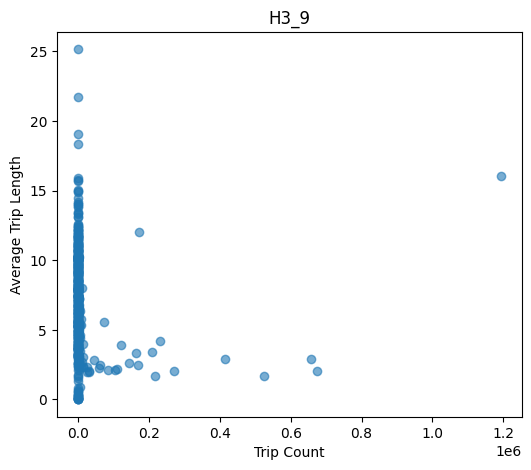

In [ ]:
# correlation of number of trips and trip length

for level in levels:

    plt.figure(figsize=(6,5))
    plt.scatter(

        pickup_stats[level]["trip_count"],
        pickup_stats[level]["avg_trip_length"],
        alpha=0.6
    )

    plt.xlabel("Trip Count")
    plt.ylabel("Average Trip Length")
    plt.title(level.upper())
    plt.show()


In [42]:
#correlation matrix

for level in levels:

    print(level)

    display(
        pickup_stats[level][
            [
                "trip_count",
                "avg_trip_length",
                "avg_price"
            ]
        ].corr()
    )

h3_7


,trip_count,avg_trip_length,avg_price
trip_count,1.000000,-0.143398,-0.081144
avg_trip_length,-0.143398,1.000000,0.809272
avg_price,-0.081144,0.809272,1.000000


h3_8


,trip_count,avg_trip_length,avg_price
trip_count,1.00000,-0.087710,-0.033730
avg_trip_length,-0.08771,1.000000,0.810972
avg_price,-0.03373,0.810972,1.000000


h3_9


,trip_count,avg_trip_length,avg_price
trip_count,1.000000,-0.067818,-0.019359
avg_trip_length,-0.067818,1.000000,0.818344
avg_price,-0.019359,0.818344,1.000000


# Spatial Hotspot Detection

TODO: explain why we use H3-8 hexagons

In [53]:
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity

In [54]:
hotspot_gdf = pickup_h3["h3_8"].copy()

hotspot_gdf["centroid"] = hotspot_gdf.geometry.centroid

hotspot_gdf["x"] = hotspot_gdf.centroid.x
hotspot_gdf["y"] = hotspot_gdf.centroid.y

C:\Users\Larissa\AppData\Local\Temp\ipykernel_22696\929294666.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["centroid"] = hotspot_gdf.geometry.centroid
C:\Users\Larissa\AppData\Local\Temp\ipykernel_22696\929294666.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["x"] = hotspot_gdf.centroid.x
C:\Users\Larissa\AppData\Local\Temp\ipykernel_22696\929294666.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  hotspot_gdf["y"] = hotspot_gdf.centroid.y


In [55]:
coords = []

for _, row in hotspot_gdf.iterrows():

    repeats = max(1, int(row["trip_count"] / 100))

    coords.extend(
        [[row["x"], row["y"]]] * repeats
    )

coords = np.array(coords)

In [56]:
gmm = GaussianMixture(
    n_components=6,
    covariance_type="full",
    random_state=42
)

gmm.fit(coords)

hotspot_gdf["cluster"] = gmm.predict(hotspot_gdf[["x", "y"]])

c:\Users\Larissa\AaA\AAA_Project_SoSe26\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but GaussianMixture was fitted without feature names
  warnings.warn(


TODO: choose n depending on the BIC

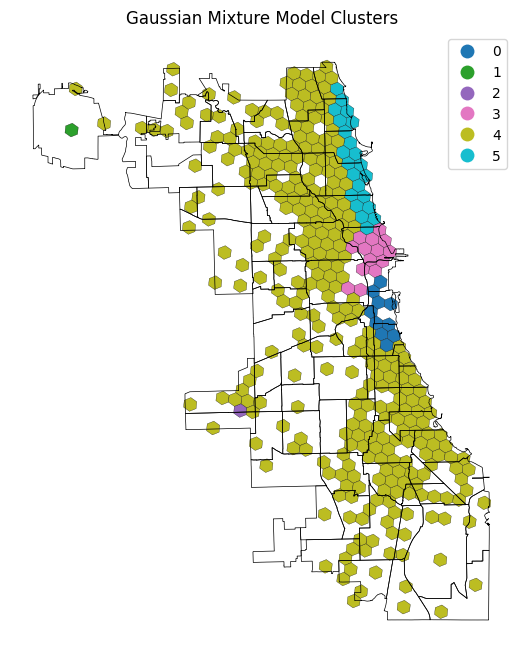

In [57]:
fig, ax = plt.subplots(figsize=(8,8))

hotspot_gdf.plot(

    column="cluster",
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)

community_areas.boundary.plot(

    ax=ax,
    color="black",
    linewidth=0.5
)

ax.set_axis_off()
plt.title("Gaussian Mixture Model Clusters")

plt.show()

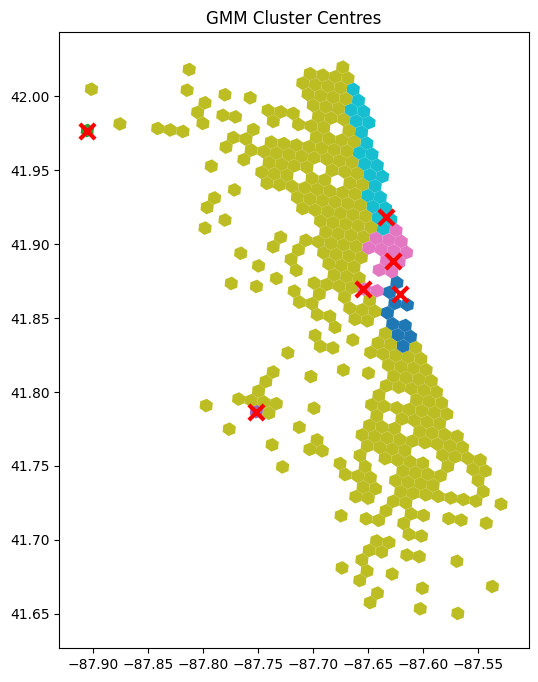

In [52]:
means = gmm.means_

fig, ax = plt.subplots(figsize=(8,8))

hotspot_gdf.plot(

    column="cluster",
    categorical=True,
    legend=False,
    ax=ax
)

ax.scatter(

    means[:,0],
    means[:,1],
    color="red",
    s=120,
    marker="x",
    linewidth=3
)

plt.title("GMM Cluster Centres")
plt.show()

In [61]:
print(type(means))
print(means.shape)
print(means)

<class 'numpy.ndarray'>
(6, 2)
[[-87.62074465  41.86659185]
 [-87.90486519  41.97696651]
 [-87.75126371  41.78668431]
 [-87.6276174   41.88855891]
 [-87.65488496  41.8695924 ]
 [-87.63389494  41.91863541]]


In [59]:
#KDE

X = hotspot_gdf[["x","y"]].values

kde = KernelDensity(
    bandwidth=0.015,
    kernel="gaussian"
)

kde.fit(X, sample_weight=hotspot_gdf["trip_count"])

hotspot_gdf["density"] = np.exp(kde.score_samples(X))

(<Figure size 600x800 with 1 Axes>,
 <Axes: title={'center': 'Kernel Density Estimation'}>)

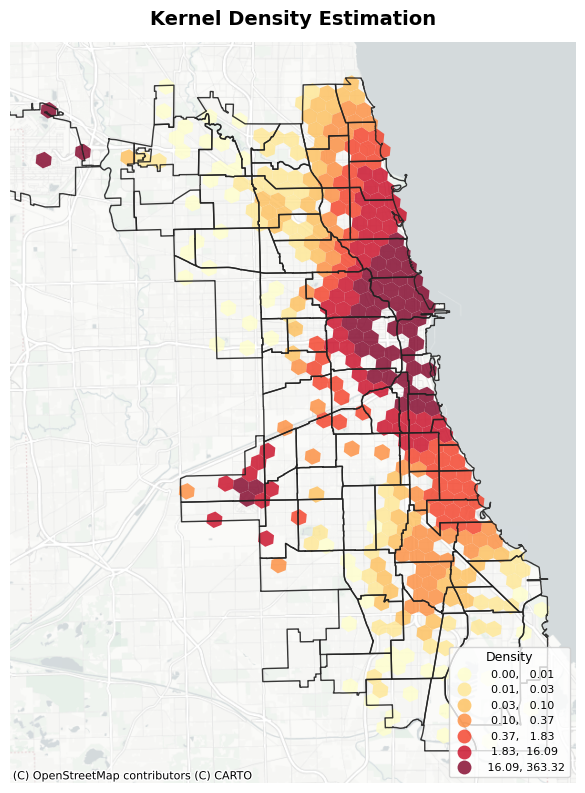

In [60]:
create_choropleth_plot(

    hotspot_gdf,
    value_col="density",
    title="Kernel Density Estimation"
)